In [3]:
# Blok 1 — Imports
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from tensorflow import keras
from google.colab import drive

In [5]:
# Blok 2 — Mount og indlæs data
drive.mount('/content/drive')
df = pd.read_csv("/content/drive/MyDrive/flowwatch/data/cleaned.csv")
print(f"Shape: {df.shape}")
print(df.head())

Mounted at /content/drive
Shape: (2520798, 79)
   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0           

In [6]:
# Blok 3 — Split og class weights
X = df.drop(columns=["Label"])
y = df["Label"]
n_classes = y.nunique()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

class_counts = y_train.value_counts()
total = len(y_train)
class_weights = {c: total / (n_classes * count) for c, count in class_counts.items()}

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Klasser: {n_classes}")

Train: (2016638, 78), Test: (504160, 78)
Klasser: 15


In [7]:
# Blok 4 — Definer og kompilér model
model = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(78,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │        10,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 15)             │           975 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,343 (75.56 KB)

 Trainable params: 19,343 (75.56 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Blok 5 — Træn
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=1024,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4438 - loss: 1600228.6250 - val_accuracy: 0.5070 - val_loss: 1814844.2500
Epoch 2/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4870 - loss: 1408325.2500 - val_accuracy: 0.5037 - val_loss: 2363462.2500
Epoch 3/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5548 - loss: 1215462.1250 - val_accuracy: 0.6788 - val_loss: 690950.6875
Epoch 4/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5466 - loss: 620668.2500 - val_accuracy: 0.3520 - val_loss: 1971420.1250
Epoch 5/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.4925 - loss: 855227.3125 - val_accuracy: 0.5598 - val_loss: 1716075.0000
Epoch 6/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5392 - loss: 946805.3125 - val_accuracy: 0.6523 - val_loss: 679912.6250
Epoch 7/20
1773/1773 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.5272 - loss: 1205345.6250 - val_accuracy: 0.6505 - val_loss: 351673.6875
Epoch 8/20


In [9]:
# Blok 6 — Evaluér
y_pred = np.argmax(model.predict(X_test), axis=1)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

15755/15755 ━━━━━━━━━━━━━━━━━━━━ 12s 770us/step
Accuracy : 0.0968
F1 macro : 0.0523

              precision    recall  f1-score   support

           0       1.00      0.10      0.18    419012
           1       0.00      0.00      0.00       390
           2       0.00      0.00      0.00     25603
           3       0.00      0.00      0.00      2057
           4       0.00      0.00      0.00     34569
           5       0.00      0.00      0.00      1046
           6       0.00      0.00      0.00      1077
           7       0.00      0.00      0.00      1186
           8       0.00      0.00      0.00         2
           9       0.00      0.00      0.00         7
          10       1.00      0.42      0.59     18139
          11       0.04      0.01      0.01       644
          12       0.00      0.00      0.00       294
          13       0.00      1.00      0.00         4
          14       0.00      0.00      0.00       130

    accuracy                           0.10    50

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


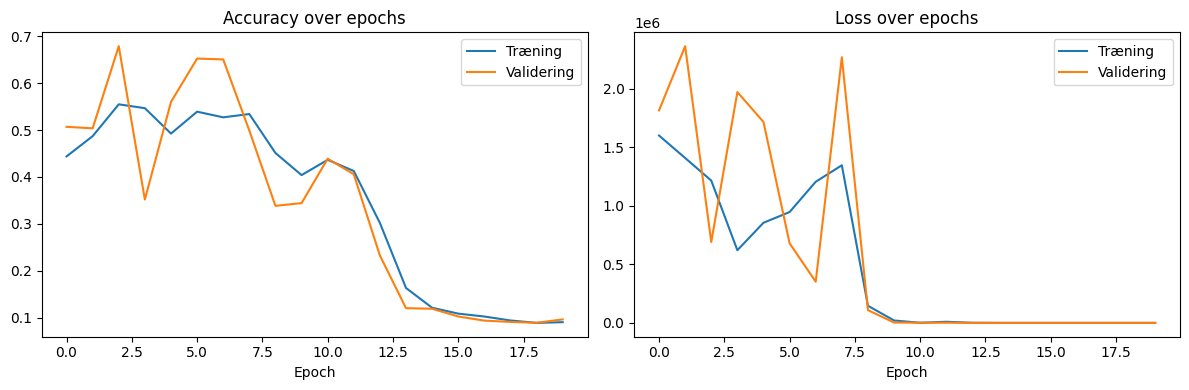

In [10]:
# Blok 7 — Training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Træning')
ax1.plot(history.history['val_accuracy'], label='Validering')
ax1.set_title('Accuracy over epochs')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'],     label='Træning')
ax2.plot(history.history['val_loss'], label='Validering')
ax2.set_title('Loss over epochs')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [12]:
!pip install onnxruntime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 17.2 MB/s eta 0:00:00


15755/15755 ━━━━━━━━━━━━━━━━━━━━ 13s 799us/step
╔══════════════════════════════════════════╗
║       XGBoost vs. DNN — Sammenligning    ║
╠══════════════════════════════════════════╣
║ Metric               XGBoost       DNN  ║
╠══════════════════════════════════════════╣
║ Accuracy              0.9955    0.0968  ║
║ F1 macro              0.7981    0.0523  ║
║ ROC AUC               0.9999    0.5647  ║
╚══════════════════════════════════════════╝

→ XGBoost vinder på F1 macro med en margin på 0.7458


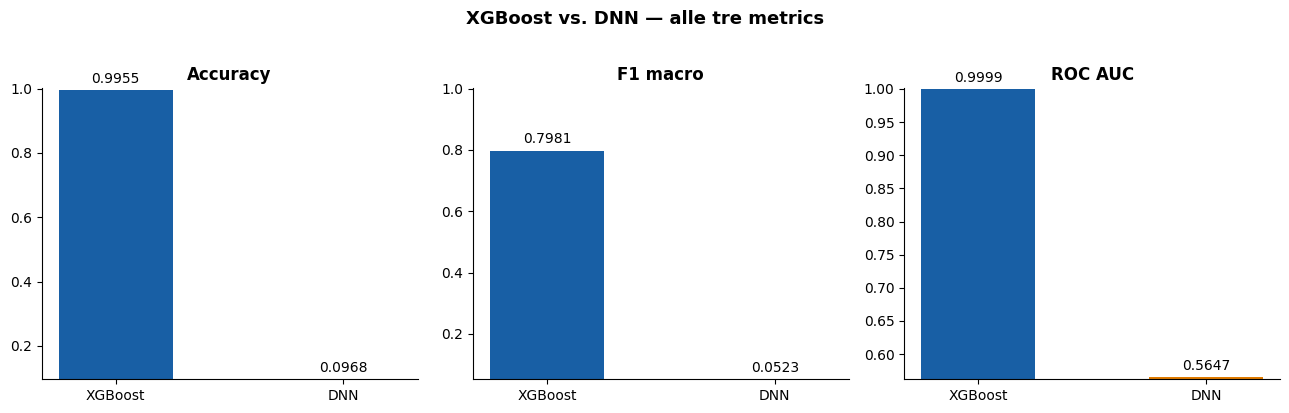

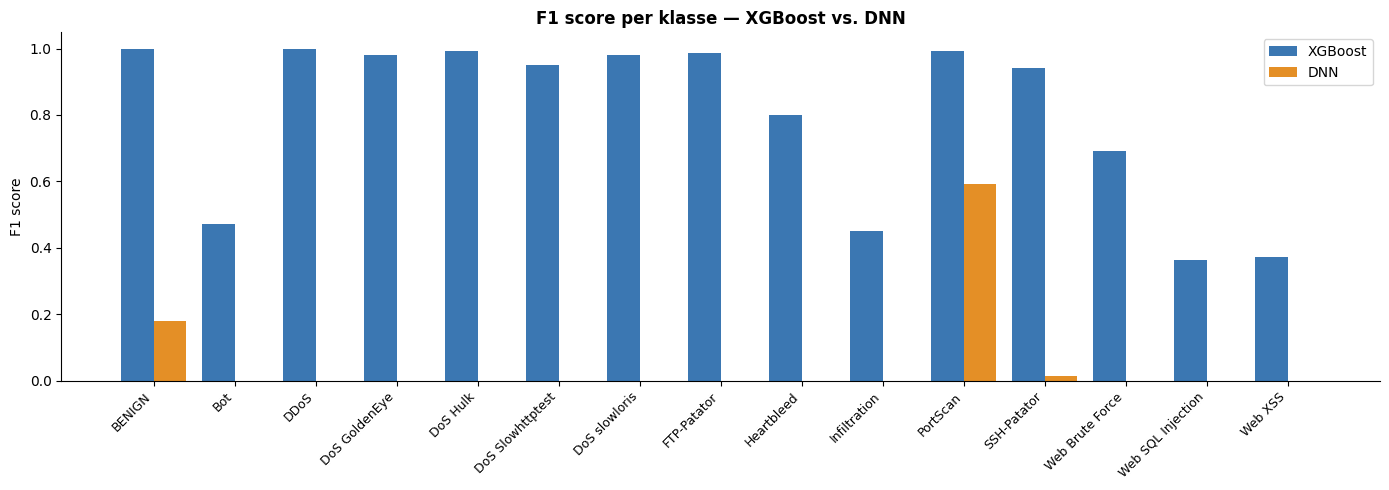

In [14]:
# Blok 8 — Sammenligning med XGBoost via ONNX
!pip install onnxruntime -q

import onnxruntime as rt
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns

# Indlæs ONNX
sess = rt.InferenceSession("/content/drive/MyDrive/flowwatch/data/flowwatch.onnx")
input_name = sess.get_inputs()[0].name

X_test_safe = X_test.copy()
X_test_safe.columns = [f"f{i}" for i in range(len(X_test.columns))]
X_test_array = X_test_safe.values.astype(np.float32)

y_pred_xgb  = sess.run(None, {input_name: X_test_array})[0]
y_prob_xgb  = sess.run(None, {input_name: X_test_array})[1]

y_prob_dnn  = model.predict(X_test)
y_pred_dnn  = np.argmax(y_prob_dnn, axis=1)

# ── Tabel ─────────────────────────────────────────────────────────────────────
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_dnn = accuracy_score(y_test, y_pred_dnn)
f1_xgb  = f1_score(y_test, y_pred_xgb, average='macro')
f1_dnn  = f1_score(y_test, y_pred_dnn, average='macro')
auc_xgb = roc_auc_score(y_test, y_prob_xgb, multi_class='ovr', average='macro')
auc_dnn = roc_auc_score(y_test, y_prob_dnn, multi_class='ovr', average='macro')

print("╔══════════════════════════════════════════╗")
print("║       XGBoost vs. DNN — Sammenligning    ║")
print("╠══════════════════════════════════════════╣")
print(f"║ {'Metric':<18} {'XGBoost':>9} {'DNN':>9}  ║")
print("╠══════════════════════════════════════════╣")
print(f"║ {'Accuracy':<18} {acc_xgb:>9.4f} {acc_dnn:>9.4f}  ║")
print(f"║ {'F1 macro':<18} {f1_xgb:>9.4f} {f1_dnn:>9.4f}  ║")
print(f"║ {'ROC AUC':<18} {auc_xgb:>9.4f} {auc_dnn:>9.4f}  ║")
print("╚══════════════════════════════════════════╝")

winner = "XGBoost" if f1_xgb > f1_dnn else "DNN"
diff   = abs(f1_xgb - f1_dnn)
print(f"\n→ {winner} vinder på F1 macro med en margin på {diff:.4f}")

# ── Søjlediagram ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics      = ['Accuracy', 'F1 macro', 'ROC AUC']
xgb_scores   = [acc_xgb, f1_xgb, auc_xgb]
dnn_scores   = [acc_dnn, f1_dnn, auc_dnn]

x = np.arange(len(metrics))
w = 0.35

for ax, metric, xv, dv in zip(axes, metrics, xgb_scores, dnn_scores):
    bars = ax.bar(['XGBoost', 'DNN'], [xv, dv], color=['#185FA5', '#e07b00'], width=0.5)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(min(xv, dv) * 0.995, 1.001)
    ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle("XGBoost vs. DNN — alle tre metrics", fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ── F1 per klasse ─────────────────────────────────────────────────────────────
from sklearn.metrics import f1_score as f1_per

label_names = ["BENIGN","Bot","DDoS","DoS GoldenEye","DoS Hulk",
               "DoS Slowhttptest","DoS slowloris","FTP-Patator",
               "Heartbleed","Infiltration","PortScan","SSH-Patator",
               "Web Brute Force","Web SQL Injection","Web XSS"]

f1_xgb_per = f1_score(y_test, y_pred_xgb, average=None)
f1_dnn_per = f1_score(y_test, y_pred_dnn, average=None)

x = np.arange(len(label_names))
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - 0.2, f1_xgb_per, 0.4, label='XGBoost', color='#185FA5', alpha=0.85)
ax.bar(x + 0.2, f1_dnn_per, 0.4, label='DNN',     color='#e07b00', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(label_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1 score')
ax.set_title('F1 score per klasse — XGBoost vs. DNN', fontsize=12, fontweight='bold')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()